### sport和tech的tf_top1000丟給GAP
 跑混淆矩陣, 看分類的正確率

In [70]:
import pandas as pd
data = pd.read_csv(r'C:\Users\USER\Documents\GitHub\psychic-spoon\0 Meeting\sport_tech_bbcnews.csv').drop(columns='Unnamed: 0')
# 你把 list 存成 .csv 之後，pandas.read_csv 會把它當成 字串，不會還原回原本的 list。
# 所以
import ast
data['Tokens'] = data['Tokens'].apply(ast.literal_eval)
import numpy as np
np.random.seed(42)
data['filename'] = data.index.map(lambda i: f'{i+1:03}.txt')
data['filename'] = data['filename'].astype(str)

gap_df = pd.read_csv(r'C:\Users\USER\Documents\GitHub\psychic-spoon\gap_doc_clusters.csv')
gap_df['filename'] = gap_df['filename'].astype(int).apply(lambda x: f"{x:03}.txt")

merged = pd.merge(data, gap_df, on='filename')
merged.head(3)

,category,filename,title,content,Tokens,cleaned_content,gap_cluster
0,sport,001.txt,Claxton hunting first major medal,British hurdler Sarah Claxton is confident sh...,"[british, hurdler, sarah, claxton, confident, ...",british hurdler sarah claxton confident win ma...,1
1,sport,002.txt,O'Sullivan could run in Worlds,Sonia O'Sullivan has indicated that she would...,"[sonia, osullivan, indicate, like, participate...",sonia osullivan indicate like participate mont...,1
2,sport,003.txt,Greene sets sights on world title,Maurice Greene aims to wipe out the pain of l...,"[maurice, greene, aim, wipe, pain, lose, olymp...",maurice greene aim wipe pain lose olympic titl...,1


### sport 分對506筆doc, tech分對392筆doc, 正確率達0.98

In [71]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_true = le.fit_transform(merged['category'])+1
y_cluster = merged['gap_cluster'].astype(int).values

print(confusion_matrix(y_true, y_cluster))
print(classification_report(y_true, y_cluster, target_names=le.classes_))

[[506   5]
 [  9 392]]
              precision    recall  f1-score   support

       sport       0.98      0.99      0.99       511
        tech       0.99      0.98      0.98       401

    accuracy                           0.98       912
   macro avg       0.98      0.98      0.98       912
weighted avg       0.98      0.98      0.98       912



---
---

### 畫圖

In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

token_counts = Counter([t for tokens in data['Tokens'] for t in tokens])
valid_tokens = {t for t, c in token_counts.items() if c>=2}
merged['filteredTokens'] = data['Tokens'].apply(lambda ts: [t for t in ts if t in valid_tokens])
merged['filtered_content'] = merged['filteredTokens'].apply(lambda ts: ' '.join(ts))

In [86]:
print(f'原本token數: {len(token_counts)}, 扣掉只出現1次的token數: {len(valid_tokens)}')

原本token數: 14474, 扣掉只出現1次的token數: 9263


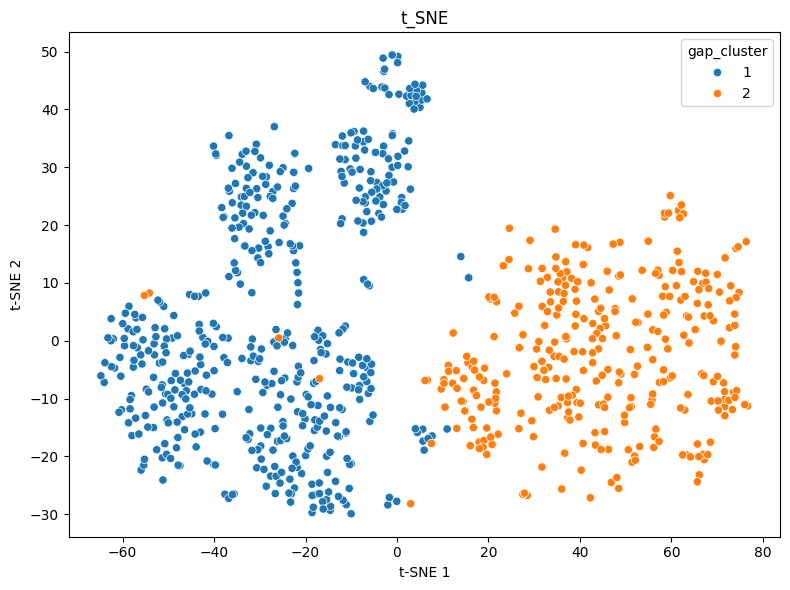

In [ ]:
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(merged['filtered_content']).toarray()
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=merged, x=X_embedded[:, 0], y=X_embedded[:, 1], hue='gap_cluster', palette='tab10')
plt.title('t_SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

---
---

### 用LogisticRegression來學習, 哪些token可以判別GAP clusters

In [110]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

X = vectorizer.fit_transform(merged['filtered_content'])
y = merged['gap_cluster']


clf = LogisticRegression(max_iter=1000)
model_clf = clf.fit(X, y)

feature_names = vectorizer.get_feature_names_out()
coef = model_clf.coef_[0]

top_pos = np.argsort(coef)[-30:]
top_neg = np.argsort(coef)[:30]

print("Cluster 1 特有詞：")
print(feature_names[top_pos])

print("\nCluster 2 特有詞：")
print(feature_names[top_neg])


Cluster 1 特有詞：
['gadget' 'law' 'system' 'net' 'sony' 'broadband' 'blog' 'microsoft'
 'email' 'information' 'internet' 'million' 'pc' 'online' 'digital'
 'network' 'company' 'music' 'site' 'firm' 'computer' 'phone' 'service'
 'mobile' 'user' 'software' 'technology' 'mr' 'use' 'people']

Cluster 2 特有詞：
['win' 'club' 'england' 'match' 'coach' 'champion' 'olympic' 'season'
 'good' 'play' 'rugby' 'team' 'cup' 'chelsea' 'final' 'ireland' 'yearold'
 'goal' 'injury' 'arsenal' 'second' 'liverpool' 'wale' 'seed' 'beat'
 'minute' 'award' 'race' 'league' 'williams']


---
---

In [112]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel

def train_lda_for_cluster(cluster_id, num_topics=3, topn=30):
    tokens = merged[merged['gap_cluster'] == cluster_id]['filteredTokens'].tolist()
    dictionary = Dictionary(tokens)
    corpus = [dictionary.doc2bow(doc) for doc in tokens]
    lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=42, iterations=100)
    print(f"\n🟦 GAP Cluster {cluster_id} - Top {num_topics} Topics:")
    for i, topic in lda.print_topics(num_topics=num_topics, num_words=topn):
        print(f"Topic {i}: {topic}")
    return lda

lda_cluster_1 = train_lda_for_cluster(1)
lda_cluster_2 = train_lda_for_cluster(2)


🟦 GAP Cluster 1 - Top 3 Topics:
Topic 0: 0.011*"win" + 0.010*"game" + 0.009*"england" + 0.008*"year" + 0.007*"world" + 0.006*"player" + 0.006*"good" + 0.006*"play" + 0.006*"coach" + 0.006*"wale" + 0.006*"team" + 0.005*"new" + 0.005*"time" + 0.005*"france" + 0.005*"come" + 0.004*"rugby" + 0.004*"ireland" + 0.004*"nation" + 0.004*"olympic" + 0.004*"test" + 0.004*"great" + 0.003*"international" + 0.003*"week" + 0.003*"look" + 0.003*"start" + 0.003*"think" + 0.003*"injury" + 0.003*"race" + 0.003*"squad" + 0.003*"match"
Topic 1: 0.011*"win" + 0.007*"second" + 0.007*"play" + 0.006*"minute" + 0.006*"open" + 0.006*"set" + 0.005*"game" + 0.005*"match" + 0.005*"final" + 0.005*"time" + 0.005*"liverpool" + 0.005*"good" + 0.005*"break" + 0.005*"year" + 0.005*"try" + 0.004*"champion" + 0.004*"beat" + 0.004*"come" + 0.004*"seed" + 0.004*"ball" + 0.004*"penalty" + 0.004*"player" + 0.003*"victory" + 0.003*"start" + 0.003*"lead" + 0.003*"williams" + 0.003*"title" + 0.003*"ireland" + 0.003*"point" + 0.0

🟨 新文件中的詞彙必須在原本的詞表中出現過
否則那部分詞會被忽略，向量稀疏，模型效果變差

若新文章出現很多從未見過的詞 → 模型會表現不佳

所以建議：詞表越大越穩定，但也越容易 overfit

🟨 模型只能預測原本訓練時學到的分類（如 cluster 1&2）
如果新來的文章語意和訓練資料完全不同，則分類可能錯誤，但這是分類模型的自然限制。

---
---

In [215]:
import pandas as pd
data = pd.read_csv(r"C:\Users\USER\Downloads\cancer.csv")
X = pd.read_csv(r"C:\Users\USER\Downloads\cancer_no_y.csv")

data['filename'] = [f'{i}' for i in range(1, 570)]
data['filename'] = data['filename'].astype(int)

cancer_gap_df = pd.read_csv(r"C:\Users\USER\Documents\GitHub\psychic-spoon\gap_diagnosis_clusters.csv")
cancer_merged = pd.merge(data, cancer_gap_df, on='filename')
cancer_merged['gap_cluster'] = cancer_merged['gap_cluster']-1

In [ ]:
cluster_preds = []
cluster_true = []

for cluster_id in sorted(cancer_merged['gap_cluster'].unique()):
    sub_df = cancer_merged[cancer_merged['gap_cluster'] == cluster_id]
    X_sub = sub_df.drop(columns=['x1', 'x2', 'gap_cluster', 'filename'])
    y_sub = sub_df['x2']

    if y_sub.nunique() < 2:
        print(f"⚠️ cluster {cluster_id} 只有一種類別，跳過")
        continue
    
    X_train, X_test, y_train, y_test = train_test_split(X_sub, y_sub, test_size=0.1, random_state=42, stratify=y_sub)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    cluster_preds.extend(y_pred)
    cluster_true.extend(y_test)

print(classification_report(cluster_true, cluster_preds))

    

⚠️ cluster 0 只有一種類別，跳過
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       1.00      0.94      0.97        17

    accuracy                           0.98        53
   macro avg       0.99      0.97      0.98        53
weighted avg       0.98      0.98      0.98        53



c:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [189]:
pd.crosstab(cancer_merged['gap_cluster'], cancer_merged['x2'])


x2,0,1
gap_cluster,,
0,0,44
1,357,168


In [186]:
from sklearn.metrics import confusion_matrix, classification_report
y_true = cancer_merged['x2']
y_cluster = cancer_merged['gap_cluster'].astype(int).values

print(confusion_matrix(y_true, y_cluster))
print(classification_report(y_true, y_cluster))

[[  0 357]
 [ 44 168]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       357
           1       0.32      0.79      0.46       212

    accuracy                           0.30       569
   macro avg       0.16      0.40      0.23       569
weighted avg       0.12      0.30      0.17       569



---
---

In [239]:
import pandas as pd
data = pd.read_csv(r"C:\Users\USER\Downloads\wine+quality\winequality-red.csv")
X = pd.read_csv(r"C:\Users\USER\Downloads\reddata_no_y.csv")

data['filename'] = [f'{i}' for i in range(1, 1600)]
data['filename'] = data['filename'].astype(int)

redwine_gap_df = pd.read_csv(r"C:\Users\USER\Documents\GitHub\psychic-spoon\gap_redwine_clusters.csv")
redwine_merged = pd.merge(data, redwine_gap_df, on='filename')
redwine_merged['gap_cluster'] = redwine_merged['gap_cluster']+2

In [240]:
redwine_merged

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,filename,gap_cluster
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1,3
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,2,3
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,3,4
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,4,4
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1595,7
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1596,7
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1597,7
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1598,7


In [241]:
pd.crosstab(redwine_merged['gap_cluster'], redwine_merged['quality'])


quality,3,4,5,6,7,8
gap_cluster,,,,,,
3,2,11,102,91,16,1
4,3,16,234,225,101,8
5,2,15,219,186,50,6
6,2,11,91,85,26,2
7,1,0,28,47,6,1
8,0,0,7,4,0,0


In [242]:
from sklearn.metrics import confusion_matrix, classification_report
y_true = redwine_merged['quality']
y_cluster = redwine_merged['gap_cluster'].astype(int).values

print(confusion_matrix(y_true, y_cluster))
print(classification_report(y_true, y_cluster))

[[  2   3   2   2   1   0]
 [ 11  16  15  11   0   0]
 [102 234 219  91  28   7]
 [ 91 225 186  85  47   4]
 [ 16 101  50  26   6   0]
 [  1   8   6   2   1   0]]
              precision    recall  f1-score   support

           3       0.01      0.20      0.02        10
           4       0.03      0.30      0.05        53
           5       0.46      0.32      0.38       681
           6       0.39      0.13      0.20       638
           7       0.07      0.03      0.04       199
           8       0.00      0.00      0.00        18

    accuracy                           0.21      1599
   macro avg       0.16      0.16      0.11      1599
weighted avg       0.36      0.21      0.25      1599



In [243]:
redwine_merged

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,filename,gap_cluster
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1,3
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,2,3
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,3,4
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,4,4
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1595,7
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1596,7
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1597,7
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1598,7


In [245]:
cluster_preds = []
cluster_true = []

for cluster_id in sorted(redwine_merged['gap_cluster'].unique()):
    sub_df = redwine_merged[redwine_merged['gap_cluster'] == cluster_id]
    X_sub = sub_df.drop(columns=['quality', 'gap_cluster', 'filename'])
    y_sub = sub_df['quality']

    vc = y_sub.value_counts()
    if len(vc) < 2 or (vc < 2).any():
        print(f"⚠️ cluster {cluster_id} 某類資料太少（{vc.to_dict()}），跳過")
        continue
    
    X_train, X_test, y_train, y_test = train_test_split(X_sub, y_sub, test_size=0.1, random_state=42, stratify=y_sub)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    cluster_preds.extend(y_pred)
    cluster_true.extend(y_test)

print(classification_report(cluster_true, cluster_preds))

    

⚠️ cluster 3 某類資料太少（{5: 102, 6: 91, 7: 16, 4: 11, 3: 2, 8: 1}），跳過


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

⚠️ cluster 7 某類資料太少（{6: 47, 5: 28, 7: 6, 3: 1, 8: 1}），跳過
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         4
           5       0.62      0.82      0.71        55
           6       0.54      0.54      0.54        52
           7       0.43      0.17      0.24        18
           8       0.00      0.00      0.00         2

    accuracy                           0.58       131
   macro avg       0.32      0.30      0.30       131
weighted avg       0.54      0.58      0.54       131



c:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [307]:
whitewine = pd.read_csv(r"C:\Users\USER\Downloads\wine+quality\winequality-white.csv")
whitewine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
.drop(columns=['id', 'diagnosis', 'Unnamed: 32'])

In [308]:
whitewine = whitewine.fillna(0).drop(columns=['quality'])

In [309]:
whitewine.to_csv('whitewine_no_y.csv', sep='\t', encoding='utf-8', index=False)

1.
半導體奈米製程資料SECOM
(n=1567) * (p = 591個參數) + pass/fail classes
https://www.kaggle.com/datasets/paresh2047/uci-semcom

2.
待更